
First 5 Rows
   Year  Month         Region    Model  Estimated_Deliveries  \
0  2023      5         Europe  Model S                 17646   
1  2015      2           Asia  Model X                  3797   
2  2019      1  North America  Model X                  8411   
3  2021      2  North America  Model 3                  6555   
4  2016     12    Middle East  Model Y                 12374   

   Production_Units  Avg_Price_USD  Battery_Capacity_kWh  Range_km  \
0             17922       92874.27                   120       704   
1              4164       62205.65                    75       438   
2              9189      117887.32                    82       480   
3              7311       89294.91                   120       712   
4             13537      114846.78                   120       661   

   CO2_Saved_tons           Source_Type  Charging_Stations  
0         1863.42  Interpolated (Month)              12207  
1          249.46    Official (Quarter)               7640

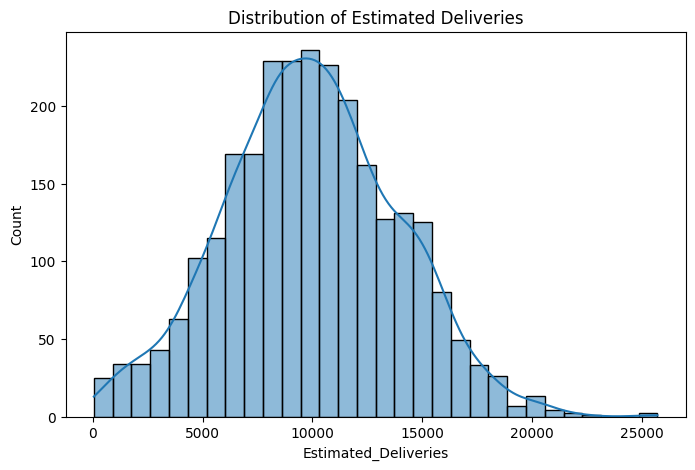

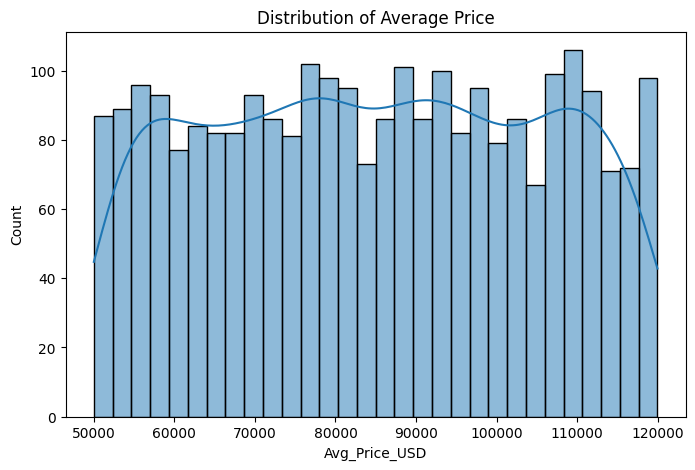

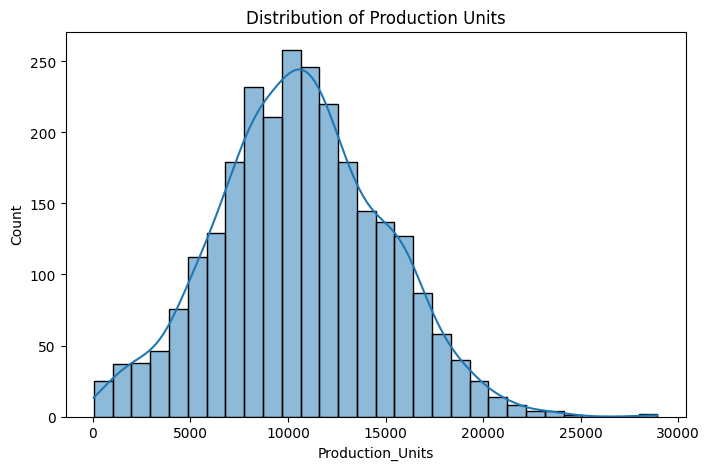

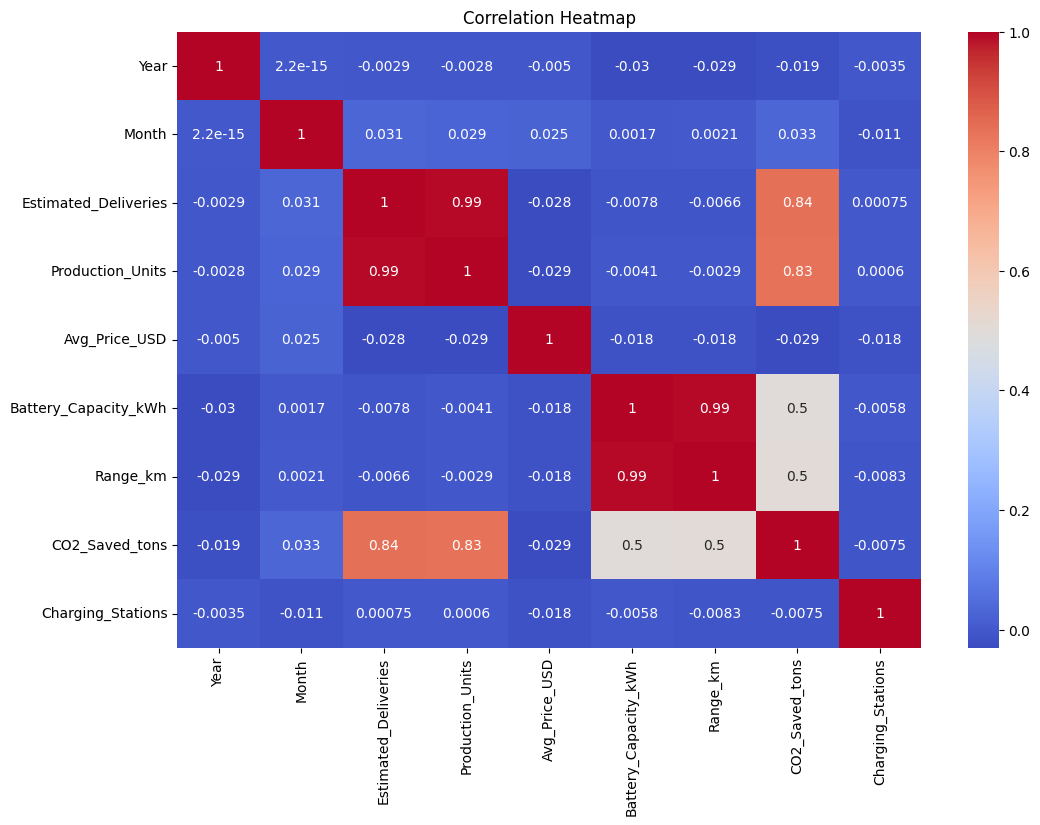

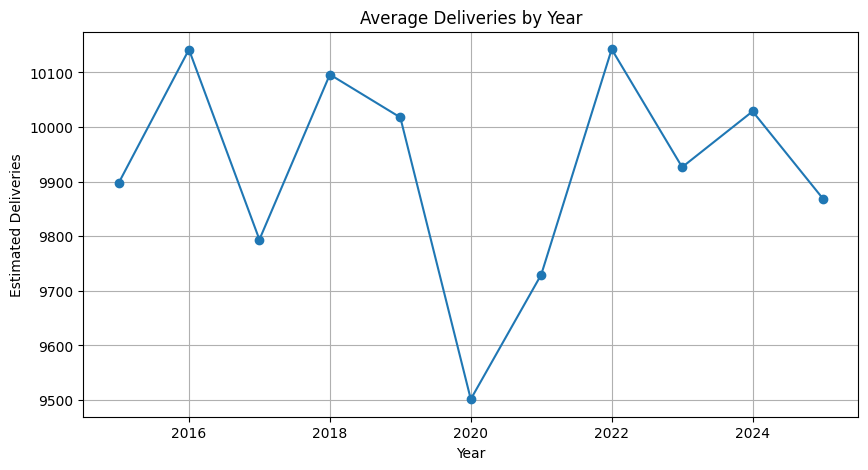

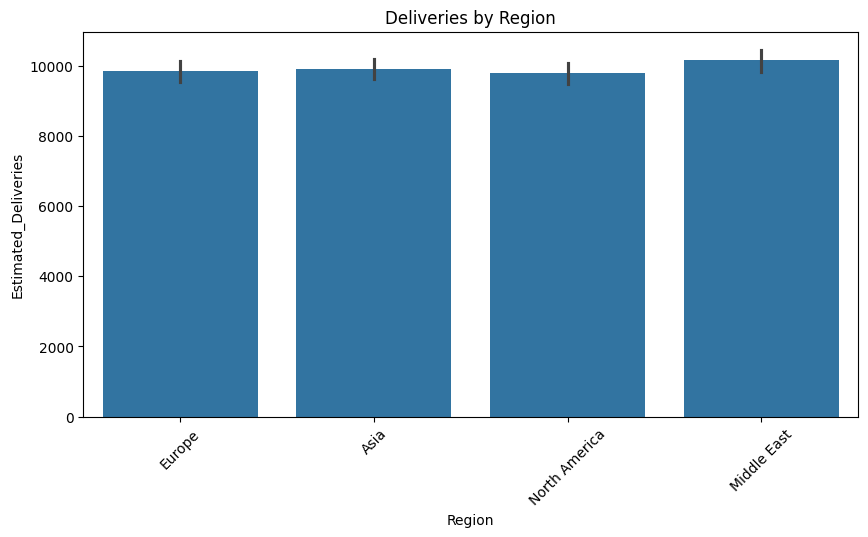

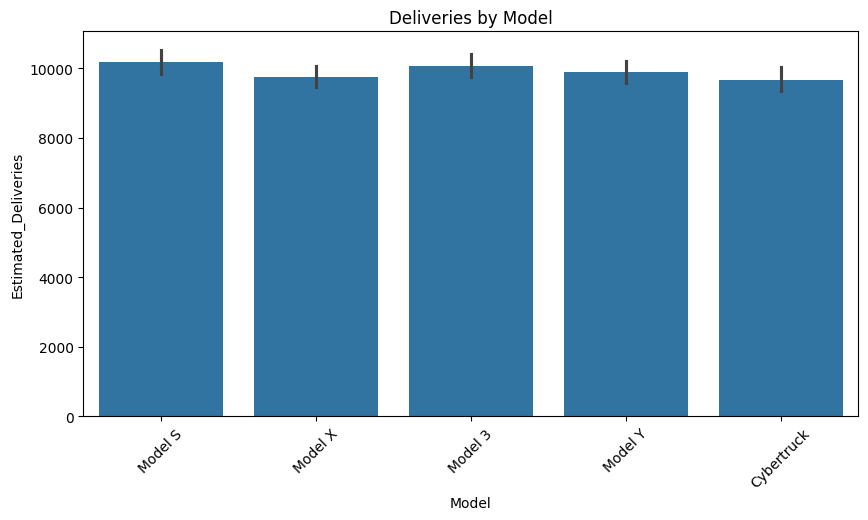


Feature Engineering Completed

LINEAR REGRESSION RESULTS
R2 Score : 0.998410342779043
MAE      : 108.86488723436852
RMSE     : 153.934689299067

RANDOM FOREST RESULTS
R2 Score : 0.999132706028787
MAE      : 68.19509469696972
RMSE     : 113.70195174942602

BEST PARAMETERS
{'model__max_depth': 15, 'model__min_samples_split': 2, 'model__n_estimators': 200}

TUNED RANDOM FOREST RESULTS
R2 Score : 0.9991519725021055
MAE      : 67.46983332615928
RMSE     : 112.43194487786963

Model Saved Successfully

MODEL COMPARISON
                 Model  R2 Score         MAE        RMSE
0    Linear Regression  0.998410  108.864887  153.934689
1        Random Forest  0.999133   68.195095  113.701952
2  Tuned Random Forest  0.999152   67.469833  112.431945


INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1875: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(



NEXT 12 MONTH FORECAST
            ds           yhat     yhat_lower     yhat_upper
132 2025-12-31  213529.706260  195157.042961  233133.792588
133 2026-01-31  185169.655353  165539.811850  204938.430890
134 2026-02-28  159843.866784  140803.474670  178104.298831
135 2026-03-31  226314.486069  207794.675043  245205.280917
136 2026-04-30  191242.025246  172627.327276  209693.764065
137 2026-05-31  210386.561699  190930.577733  230971.354705
138 2026-06-30  185025.726840  164837.156453  202659.291225
139 2026-07-31  214030.091480  194854.766265  233079.118352
140 2026-08-31  171945.664530  153820.100174  191109.751146
141 2026-09-30  207346.026096  188829.191268  226098.916177
142 2026-10-31  205166.318151  187167.983545  224669.679826
143 2026-11-30  208874.506907  191130.401021  226846.659846


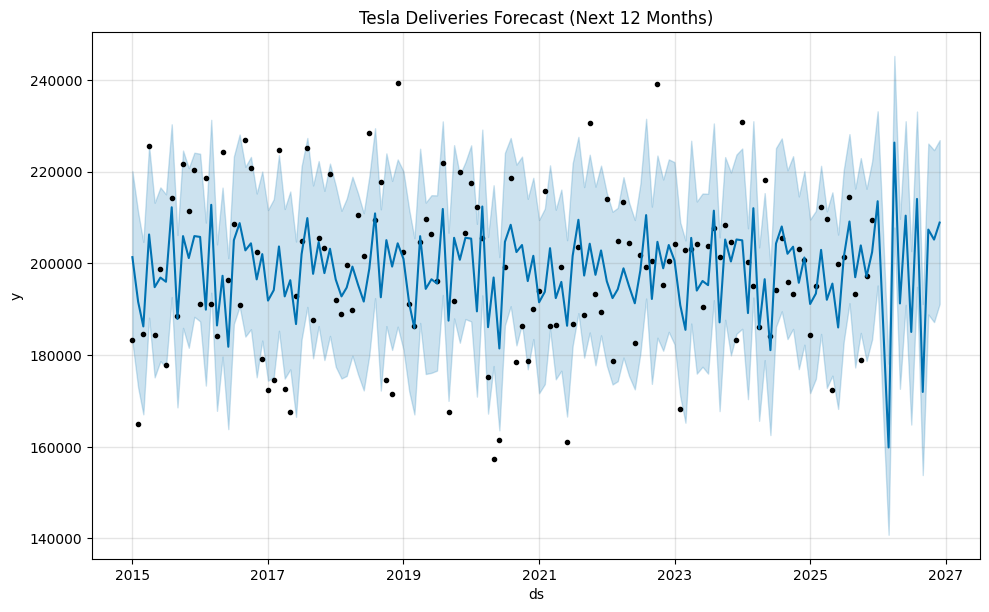

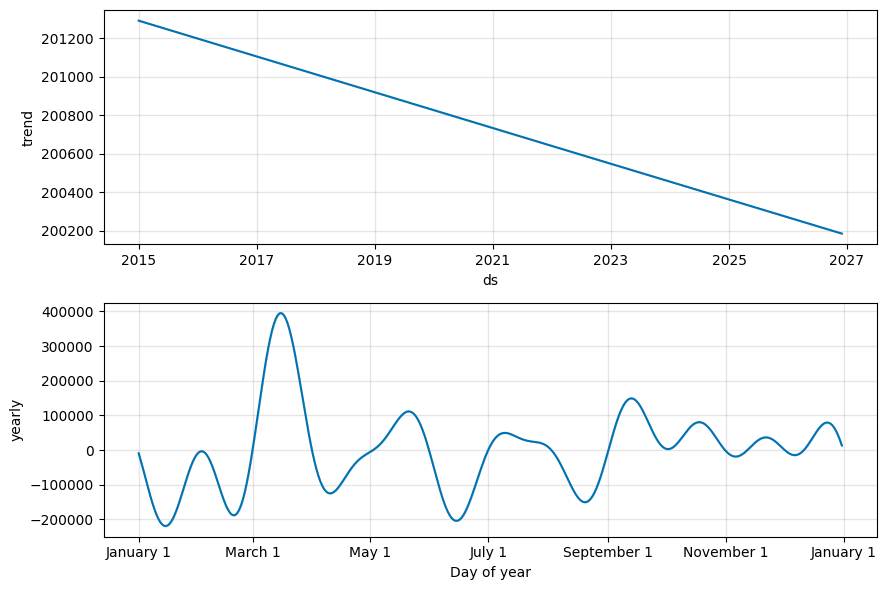


PIPELINE EXECUTED SUCCESSFULLY


In [ ]:
# ============================================
# TESLA SALES/PRICE DATA - END TO END ML PIPELINE
# ============================================

# =====================================================
# 1. IMPORT LIBRARIES
# =====================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV
)

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)

from sklearn.linear_model import LinearRegression

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

import joblib

# =====================================================
# 2. LOAD DATASET
# =====================================================

df = pd.read_csv("tesla_deliveries_dataset_2015_2025.csv")

print("\nFirst 5 Rows")
print(df.head())

print("\nDataset Shape")
print(df.shape)

print("\nDataset Info")
print(df.info())

# =====================================================
# 3. DATA CLEANING
# =====================================================

print("\nMissing Values")
print(df.isnull().sum())

df.drop_duplicates(inplace=True)

print("\nShape After Removing Duplicates")
print(df.shape)

# =====================================================
# 4. EXPLORATORY DATA ANALYSIS (EDA)
# =====================================================

# Deliveries Distribution

plt.figure(figsize=(8,5))
sns.histplot(df["Estimated_Deliveries"], bins=30, kde=True)
plt.title("Distribution of Estimated Deliveries")
plt.show()

# Price Distribution

plt.figure(figsize=(8,5))
sns.histplot(df["Avg_Price_USD"], bins=30, kde=True)
plt.title("Distribution of Average Price")
plt.show()

# Production Units Distribution

plt.figure(figsize=(8,5))
sns.histplot(df["Production_Units"], bins=30, kde=True)
plt.title("Distribution of Production Units")
plt.show()

# Correlation Heatmap

plt.figure(figsize=(12,8))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

# Deliveries Trend by Year

yearly_delivery = (
    df.groupby("Year")["Estimated_Deliveries"]
    .mean()
)

plt.figure(figsize=(10,5))
yearly_delivery.plot(marker="o")
plt.title("Average Deliveries by Year")
plt.ylabel("Estimated Deliveries")
plt.grid(True)
plt.show()

# Deliveries by Region

plt.figure(figsize=(10,5))

sns.barplot(
    data=df,
    x="Region",
    y="Estimated_Deliveries"
)

plt.xticks(rotation=45)
plt.title("Deliveries by Region")
plt.show()

# Deliveries by Model

plt.figure(figsize=(10,5))

sns.barplot(
    data=df,
    x="Model",
    y="Estimated_Deliveries"
)

plt.xticks(rotation=45)
plt.title("Deliveries by Model")
plt.show()

# =====================================================
# 5. FEATURE ENGINEERING
# =====================================================

df["Delivery_Production_Ratio"] = (
    df["Estimated_Deliveries"]
    /
    df["Production_Units"]
)

df["Price_per_kWh"] = (
    df["Avg_Price_USD"]
    /
    df["Battery_Capacity_kWh"]
)

df["Price_per_km"] = (
    df["Avg_Price_USD"]
    /
    df["Range_km"]
)

df["Quarter"] = (
    (df["Month"] - 1) // 3
) + 1

print("\nFeature Engineering Completed")

# =====================================================
# 6. DEFINE FEATURES AND TARGET
# =====================================================

X = df.drop(
    columns=["Estimated_Deliveries"]
)

y = df["Estimated_Deliveries"]

# =====================================================
# 7. CATEGORICAL & NUMERICAL COLUMNS
# =====================================================

categorical_columns = [
    "Region",
    "Model",
    "Source_Type"
]

numerical_columns = [
    "Year",
    "Month",
    "Production_Units",
    "Avg_Price_USD",
    "Battery_Capacity_kWh",
    "Range_km",
    "CO2_Saved_tons",
    "Charging_Stations",
    "Delivery_Production_Ratio",
    "Price_per_kWh",
    "Price_per_km",
    "Quarter"
]

# =====================================================
# 8. PREPROCESSING PIPELINE
# =====================================================

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_columns
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_columns
        )
    ]
)

# =====================================================
# 9. TRAIN TEST SPLIT
# =====================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# =====================================================
# 10. LINEAR REGRESSION MODEL
# =====================================================

lr_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            LinearRegression()
        )
    ]
)

lr_pipeline.fit(
    X_train,
    y_train
)

lr_predictions = lr_pipeline.predict(
    X_test
)

lr_r2 = r2_score(
    y_test,
    lr_predictions
)

lr_mae = mean_absolute_error(
    y_test,
    lr_predictions
)

lr_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        lr_predictions
    )
)

print("\nLINEAR REGRESSION RESULTS")

print("R2 Score :", lr_r2)
print("MAE      :", lr_mae)
print("RMSE     :", lr_rmse)

# =====================================================
# 11. RANDOM FOREST MODEL
# =====================================================

rf_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            RandomForestRegressor(
                random_state=42
            )
        )
    ]
)

rf_pipeline.fit(
    X_train,
    y_train
)

rf_predictions = rf_pipeline.predict(
    X_test
)

rf_r2 = r2_score(
    y_test,
    rf_predictions
)

rf_mae = mean_absolute_error(
    y_test,
    rf_predictions
)

rf_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        rf_predictions
    )
)

print("\nRANDOM FOREST RESULTS")

print("R2 Score :", rf_r2)
print("MAE      :", rf_mae)
print("RMSE     :", rf_rmse)

# =====================================================
# 12. HYPERPARAMETER TUNING
# =====================================================

param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [5, 10, 15],
    "model__min_samples_split": [2, 5]
}

grid_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid_search.fit(
    X_train,
    y_train
)

print("\nBEST PARAMETERS")
print(grid_search.best_params_)

best_model = grid_search.best_estimator_

best_predictions = best_model.predict(
    X_test
)

best_r2 = r2_score(
    y_test,
    best_predictions
)

best_mae = mean_absolute_error(
    y_test,
    best_predictions
)

best_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        best_predictions
    )
)

print("\nTUNED RANDOM FOREST RESULTS")

print("R2 Score :", best_r2)
print("MAE      :", best_mae)
print("RMSE     :", best_rmse)

# =====================================================
# 13. SAVE BEST MODEL
# =====================================================

joblib.dump(
    best_model,
    "best_tesla_model.pkl"
)

print("\nModel Saved Successfully")

# =====================================================
# 14. MODEL COMPARISON TABLE
# =====================================================

results = pd.DataFrame({

    "Model": [
        "Linear Regression",
        "Random Forest",
        "Tuned Random Forest"
    ],

    "R2 Score": [
        lr_r2,
        rf_r2,
        best_r2
    ],

    "MAE": [
        lr_mae,
        rf_mae,
        best_mae
    ],

    "RMSE": [
        lr_rmse,
        rf_rmse,
        best_rmse
    ]
})

print("\nMODEL COMPARISON")
print(results)

# =====================================================
# 15. TIME SERIES FORECASTING
# =====================================================

from prophet import Prophet

df["Date"] = pd.to_datetime(
    df["Year"].astype(str)
    + "-"
    + df["Month"].astype(str)
    + "-01"
)

monthly_sales = (
    df.groupby("Date")
    ["Estimated_Deliveries"]
    .sum()
    .reset_index()
)

prophet_df = monthly_sales.rename(
    columns={
        "Date": "ds",
        "Estimated_Deliveries": "y"
    }
)

forecast_model = Prophet()

forecast_model.fit(
    prophet_df
)

future_dates = (
    forecast_model
    .make_future_dataframe(
        periods=12,
        freq="M"
    )
)

forecast = (
    forecast_model
    .predict(future_dates)
)

print("\nNEXT 12 MONTH FORECAST")

print(
    forecast[
        [
            "ds",
            "yhat",
            "yhat_lower",
            "yhat_upper"
        ]
    ].tail(12)
)

# =====================================================
# 16. FORECAST PLOT
# =====================================================

forecast_model.plot(
    forecast
)

plt.title(
    "Tesla Deliveries Forecast (Next 12 Months)"
)

plt.show()

# =====================================================
# 17. COMPONENT PLOTS
# =====================================================

forecast_model.plot_components(
    forecast
)

plt.show()

print("\nPIPELINE EXECUTED SUCCESSFULLY")